# DiffMI — Training-Free Model Inversion Attack

In [ ]:

# CELL 1 — Install packages (run once per session)

import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q', '--no-deps'])

# Install only what is missing, no version conflicts
!pip install diffusers==0.30.0 -q --no-deps
!pip install accelerate==0.27.2 -q --no-deps
!pip install transformers==4.41.0 -q --no-deps
!pip install facenet-pytorch -q --no-deps
!pip install huggingface_hub -q
!pip install timm -q


print('Packages installed')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 280.0/280.0 kB 11.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 39.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 29.0 MB/s eta 0:00:00
Packages installed


In [ ]:
!pip install -q tokenizers -U
!pip install -q transformers -U
!pip install -q diffusers -U
!pip install -q accelerate -U
!pip install -q facenet-pytorch --no-deps
!pip install -q timm
print("Done — Restart Session now")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 56.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
transformers 5.11.0 requires tokenizers<=0.23.0,>=0.22.0, but you have tokenizers 0.23.1 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 43.6 MB/s eta 0:00:00
Done — Restart Session now


In [ ]:
!pip install torch torchvision --upgrade -q
print("Done — Runtime → Restart Session NOW")
import tokenizers, transformers, diffusers, torch
print(tokenizers.__version__)
print(transformers.__version__)
print(diffusers.__version__)
print(torch.__version__)
print(torch.cuda.is_available())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 532.3/532.3 MB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.2/366.2 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.0/206.0 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.5/201.5 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 49.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 57.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.1/214.1 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 43.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.5/59.5 MB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.9/2

In [ ]:
import tokenizers, transformers, diffusers, torch
print(tokenizers.__version__)
print(transformers.__version__)
print(diffusers.__version__)
print(torch.__version__)
print(torch.cuda.is_available())

0.22.2
5.11.0
0.38.0
2.12.0+cu130
True


In [ ]:

# CELL 2 — Imports and device check

import torch
import torch.nn.functional as F
import numpy as np
import os, gc, glob, random, warnings
from scipy import stats
from PIL import Image
import torchvision.transforms as T
import matplotlib.pyplot as plt
from tqdm import tqdm
from IPython.display import display
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch : {torch.__version__}')
print(f'Device  : {device}')
if device.type == 'cuda':
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
else:
    print('WARNING: No GPU detected. Go to Runtime > Change runtime type > T4 GPU')

PyTorch : 2.12.0+cu130
Device  : cuda
GPU     : Tesla T4


In [ ]:

# CELL 3 — Load DDPM (downloads ~450MB once)

from diffusers import UNet2DModel, DDPMScheduler

print('Downloading DDPM pretrained on CelebA-HQ 256x256 ...')
unet = UNet2DModel.from_pretrained(
    'google/ddpm-celebahq-256',
    use_safetensors=False
).to(device).eval()

scheduler = DDPMScheduler.from_pretrained('google/ddpm-celebahq-256')
print('DDPM ready')

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


config.json:   0%|          | 0.00/790 [00:00<?, ?B/s]

diffusion_pytorch_model.bin:   0%|          | 0.00/455M [00:00<?, ?B/s]

scheduler_config.json:   0%|          | 0.00/256 [00:00<?, ?B/s]

DDPM ready


In [ ]:

# CELL 4 — Load ArcFace + MTCNN

from facenet_pytorch import InceptionResnetV1, MTCNN

arcface = InceptionResnetV1(pretrained='vggface2').eval().to(device)
mtcnn   = MTCNN(image_size=160, margin=32, keep_all=False, device=device)
print('ArcFace + MTCNN ready')

  0%|          | 0.00/107M [00:00<?, ?B/s]

ArcFace + MTCNN ready


In [ ]:

# CELL 5 — Core helper functions


def free_mem():
    gc.collect()
    torch.cuda.empty_cache()


def generate_image(latent, steps=20):
    """Run DDPM denoising: latent (1,3,256,256) -> image (1,3,256,256) in [-1,1]"""
    scheduler.set_timesteps(steps)
    x = latent.clone().to(device)
    with torch.no_grad():
        for t in scheduler.timesteps:
            out   = unet(x, t)
            x     = scheduler.step(out.sample, t, x).prev_sample
    return x


def to_pil(tensor):
    """Convert (1,3,H,W) tensor [-1,1] to PIL Image."""
    img = (tensor.squeeze().cpu().clamp(-1, 1) + 1) / 2   # [0,1]
    img = (img * 255).byte().permute(1, 2, 0).numpy()
    return Image.fromarray(img)


def get_face_embedding(inp):
    """
    inp: tensor (1,3,H,W) in [-1,1]  OR  PIL Image
    Returns (embedding (1,512), detection_confidence)
    embedding is None if no face detected.
    """
    pil = to_pil(inp) if torch.is_tensor(inp) else inp
    try:
        face, prob = mtcnn(pil, return_prob=True)
    except Exception:
        return None, 0.0
    if face is None or prob is None:
        return None, 0.0
    with torch.no_grad():
        emb = arcface(face.unsqueeze(0).to(device))
        emb = F.normalize(emb, p=2, dim=1)
    return emb, float(prob)


def cosine_sim(a, b):
    return F.cosine_similarity(a, b, dim=1).item()


print('Helper functions defined')

Helper functions defined


Face detected : True
Confidence    : 1.0000
Embedding dim : torch.Size([1, 512])


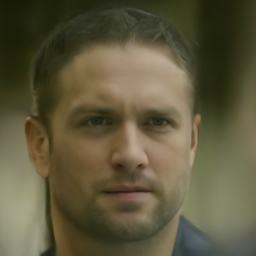

Sanity check passed — pipeline works end to end


In [ ]:

# CELL 6 — Sanity check: generate one face

free_mem()
test_latent = torch.randn(1, 3, 256, 256).to(device)
test_img    = generate_image(test_latent, steps=20)
test_pil    = to_pil(test_img)

emb, conf = get_face_embedding(test_img)
print(f'Face detected : {emb is not None}')
print(f'Confidence    : {conf:.4f}')
if emb is not None:
    print(f'Embedding dim : {emb.shape}')   # expect (1, 512)
display(test_pil)
print('Sanity check passed — pipeline works end to end')

In [ ]:

# CELL 7 — Step (a): Build latent code pool
# Paper Section III-D
# Filters random Gaussian codes by:
#   1. D'Agostino K2 normality test
#   2. MTCNN face detection
# Run once — saves to pool.pt and reloads next time.


def build_pool(pool_size=100, tau_k=0.05, tau_d=0.80,
               steps=20, path='pool.pt'):

    if os.path.exists(path):
        data = torch.load(path, weights_only=False)
        print(f'Loaded existing pool: {len(data)} codes')
        return data

    pool, tries = [], 0
    bar = tqdm(total=pool_size, desc='Building pool')

    while len(pool) < pool_size:
        tries += 1
        free_mem()

        # Sample random Gaussian latent
        xG = torch.randn(1, 3, 256, 256).to(device)

        # --- Stage 1: Normality test (fast) ---
        flat = xG.flatten().cpu().numpy()
        samp = flat[np.random.choice(len(flat), 5000, replace=False)]
        _, p_k = stats.normaltest(samp)
        if p_k < tau_k:
            continue

        # --- Stage 2: Face detection (slower) ---
        x_hat = generate_image(xG, steps=steps)
        _, p_d = get_face_embedding(x_hat)
        if p_d < tau_d:
            continue

        pool.append((xG.cpu(), x_hat.cpu()))
        bar.update(1)

    bar.close()
    torch.save(pool, path)
    print(f'Pool saved: {len(pool)} codes in {tries} attempts '
          f'({len(pool)/tries*100:.1f}% acceptance rate)')
    return pool


# Build pool — ~5 mins on T4 with these settings
pool = build_pool(pool_size=100, tau_k=0.05, tau_d=0.80,
                  steps=20, path='pool.pt')

Building pool: 100%|██████████| 100/100 [04:51<00:00,  2.91s/it]


Pool saved: 100 codes in 103 attempts (97.1% acceptance rate)


In [ ]:

# CELL 8 — Step (b): Top-N selection
# Paper Section III-E
# Rank pool codes by similarity to target embedding.


def select_top_n(pool, target_emb, N=3):
    scored = []
    for xG, x_hat in tqdm(pool, desc='Ranking pool'):
        emb, _ = get_face_embedding(x_hat.to(device))
        sim     = cosine_sim(emb, target_emb) if emb is not None else -1.0
        scored.append((xG, sim))
    scored.sort(key=lambda x: x[1], reverse=True)
    top = scored[:N]
    print(f'Top-{N} initial similarities: {[round(s,4) for _,s in top]}')
    return top


print('select_top_n defined')

select_top_n defined


In [ ]:

# CELL 9 — Step (c): Ranked Adversary attack
# Paper Section III-F
# Uses finite-difference gradient estimation so
# DDPM never needs to store gradients -> no OOM.


def attack_one(xG_init, target_emb,
               epsilon=35.0,   # L2 perturbation budget
               tau_c=0.85,     # confidence threshold for early stop
               t_max=30,       # max iterations
               steps=15,       # DDPM denoising steps per call
               n_fd=8,         # finite-difference directions
               lr=2.0,         # step size
               verbose=True):
    """
    Optimize perturbation delta on xG_init so that
    generate_image(xG_init + delta) matches target_emb.
    """
    free_mem()
    xG    = xG_init.clone().to(device)
    delta = torch.zeros_like(xG)
    best_sim, best_img = -1.0, None

    for i in range(t_max):
        free_mem()

        # ---- Generate current image (no grad) ----
        with torch.no_grad():
            x_hat = generate_image((xG + delta).clamp(-3, 3), steps=steps)

        emb, _ = get_face_embedding(x_hat)
        if emb is None:
            if verbose: print(f'  iter {i:03d}: no face detected')
            continue

        sim = cosine_sim(emb, target_emb)
        if sim > best_sim:
            best_sim = sim
            best_img = x_hat.cpu()

        if verbose and i % 5 == 0:
            print(f'  iter {i:03d}: sim={sim:.4f}  best={best_sim:.4f}')

        # ---- Early stopping ----
        if sim >= tau_c:
            print(f'  Early stop at iter {i}  sim={sim:.4f} >= tau_c={tau_c}')
            break

        # ---- Finite-difference gradient estimate ----
        with torch.no_grad():
            grad = torch.zeros_like(delta)
            for _ in range(n_fd):
                free_mem()
                d        = torch.randn_like(delta)
                d        = d / (d.norm() + 1e-8)
                x_plus   = generate_image((xG + delta + d).clamp(-3,3), steps=steps)
                emb_p, _ = get_face_embedding(x_plus)
                if emb_p is None: continue
                grad += (cosine_sim(emb_p, target_emb) - sim) * d
            grad /= max(n_fd, 1)

            # Gradient ascent step
            delta = delta + lr * grad

            # Project back onto L2 ball
            n = delta.norm()
            if n > epsilon:
                delta = delta * (epsilon / n)

    return best_img, best_sim


def ranked_adversary(top_n, target_emb,
                     epsilon=35.0, tau_c=0.85,
                     t_max=30, steps=15):
    """Try each candidate in rank order; stop when tau_c is met."""
    best_img, best_sim = None, -1.0
    for rank, (xG, init_sim) in enumerate(top_n):
        print(f'\n── Rank {rank+1}  init_sim={init_sim:.4f} ──')
        img, sim = attack_one(xG, target_emb,
                               epsilon=epsilon, tau_c=tau_c,
                               t_max=t_max, steps=steps)
        if img is not None and sim > best_sim:
            best_sim, best_img = sim, img
        if sim >= tau_c:
            print(f'Rank {rank+1} succeeded!')
            break
    return best_img, best_sim


print('Attack functions defined')

Attack functions defined


Generating target face...
Target ready  conf=0.9997


Ranking pool: 100%|██████████| 100/100 [00:04<00:00, 23.00it/s]


Top-3 initial similarities: [0.5597, 0.4922, 0.4813]

Running attack...

── Rank 1  init_sim=0.5597 ──
  iter 000: sim=-0.2542  best=-0.2542
  iter 005: sim=0.3404  best=0.4699
  iter 010: sim=0.3382  best=0.4699
  iter 015: sim=0.2600  best=0.4774

── Rank 2  init_sim=0.4922 ──
  iter 000: sim=0.2824  best=0.2824
  iter 005: sim=0.3058  best=0.5485
  iter 010: sim=0.3043  best=0.5485
  iter 015: sim=0.3998  best=0.5485

── Rank 3  init_sim=0.4813 ──
  iter 000: sim=0.0563  best=0.0563
  iter 005: sim=-0.0095  best=0.5035
  iter 010: sim=0.0688  best=0.5035
  iter 015: sim=-0.0052  best=0.5035


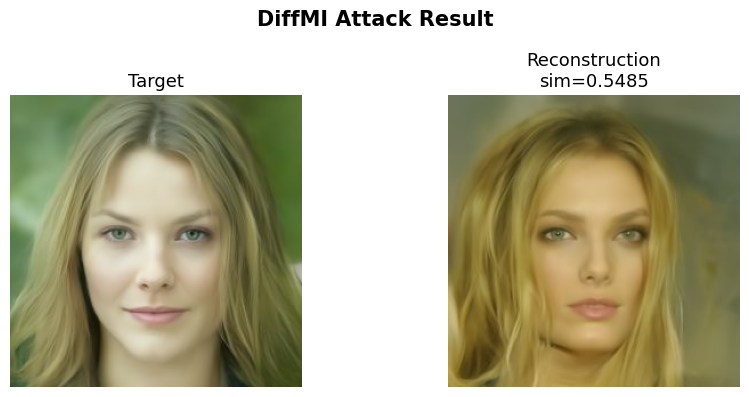


Final similarity : 0.5485
Decision threshold (tau_f=0.23): PASS
Attack success   : YES


In [ ]:

# CELL 10 — Demo attack on a synthetic target

free_mem()

# Generate a random target face
print('Generating target face...')
target_emb = None
while target_emb is None:
    lat        = torch.randn(1, 3, 256, 256).to(device)
    target_img = generate_image(lat, steps=25)
    target_emb, conf = get_face_embedding(target_img)

print(f'Target ready  conf={conf:.4f}')

# Step (b)
top_n = select_top_n(pool, target_emb, N=3)
free_mem()

# Step (c)
print('\nRunning attack...')
final_img, final_sim = ranked_adversary(
    top_n, target_emb,
    epsilon=35.0, tau_c=0.85,
    t_max=20, steps=15
)

# Show results
fig, ax = plt.subplots(1, 2, figsize=(9, 4))
ax[0].imshow(to_pil(target_img)); ax[0].set_title('Target',           fontsize=13); ax[0].axis('off')
ax[1].imshow(to_pil(final_img));  ax[1].set_title(f'Reconstruction\nsim={final_sim:.4f}', fontsize=13); ax[1].axis('off')
plt.suptitle('DiffMI Attack Result', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('demo_result.png', dpi=150)
plt.show()

print(f'\nFinal similarity : {final_sim:.4f}')
print(f'Decision threshold (tau_f=0.23): {"PASS" if final_sim>=0.23 else "FAIL"}')
print(f'Attack success   : {"YES" if final_sim>=0.23 else "NO"}')

In [ ]:
# Method 2: kaggle mirror
!pip install -q kaggle
# OR use gdown from Google Drive mirror
!pip install -q gdown
import gdown
gdown.download(
    'https://drive.google.com/uc?id=1WO5Meh_yAau00Gm2Rz2Pc0SRldLQYigT',
    'lfw.tgz', quiet=False
)

Downloading...
From (original): https://drive.google.com/uc?id=1WO5Meh_yAau00Gm2Rz2Pc0SRldLQYigT
From (redirected): https://drive.google.com/uc?id=1WO5Meh_yAau00Gm2Rz2Pc0SRldLQYigT&confirm=t&uuid=b9004a6e-7a7f-42a8-9183-7d01b65f72fa
To: /content/lfw.tgz
100%|██████████| 1.23G/1.23G [00:19<00:00, 63.0MB/s]


'lfw.tgz'

In [ ]:
import os

# Check current directory
print("Files in current dir:")
print(os.listdir('.'))

# Check if tgz exists
print(f"\nlfw.tgz exists: {os.path.exists('lfw.tgz')}")
print(f"lfw folder exists: {os.path.exists('lfw')}")

Files in current dir:
['.config', 'lfw.tgz', 'demo_result.png', 'pool.pt', 'sample_data']

lfw.tgz exists: True
lfw folder exists: False


In [ ]:
import zipfile, os

print("Extracting...")
with zipfile.ZipFile('archive.zip', 'r') as z:
    z.extractall('.')

# Find where it extracted
for folder in ['lfw', 'lfw-deepfunneled', 'lfw_funneled']:
    if os.path.exists(folder):
        count = len(os.listdir(folder))
        print(f"Found: {folder}/ with {count} identities")
        lfw_dir = folder
        break

Extracting...
Found: lfw-deepfunneled/ with 1 identities


In [ ]:
import os, zipfile

# See actual structure inside zip
with zipfile.ZipFile('archive.zip', 'r') as z:
    names = z.namelist()
    print(f"Total files in zip: {len(names)}")
    print("First 20 entries:")
    for n in names[:20]:
        print(f"  {n}")
# Check what we actually have
for root, dirs, files in os.walk('lfw-deepfunneled'):
    level = root.count(os.sep)
    if level < 3:
        print(f"{root}/ — {len(files)} files, {len(dirs)} subdirs")

Total files in zip: 13243
First 20 entries:
  lfw-deepfunneled/lfw-deepfunneled/AJ_Cook/AJ_Cook_0001.jpg
  lfw-deepfunneled/lfw-deepfunneled/AJ_Lamas/AJ_Lamas_0001.jpg
  lfw-deepfunneled/lfw-deepfunneled/Aaron_Eckhart/Aaron_Eckhart_0001.jpg
  lfw-deepfunneled/lfw-deepfunneled/Aaron_Guiel/Aaron_Guiel_0001.jpg
  lfw-deepfunneled/lfw-deepfunneled/Aaron_Patterson/Aaron_Patterson_0001.jpg
  lfw-deepfunneled/lfw-deepfunneled/Aaron_Peirsol/Aaron_Peirsol_0001.jpg
  lfw-deepfunneled/lfw-deepfunneled/Aaron_Peirsol/Aaron_Peirsol_0002.jpg
  lfw-deepfunneled/lfw-deepfunneled/Aaron_Peirsol/Aaron_Peirsol_0003.jpg
  lfw-deepfunneled/lfw-deepfunneled/Aaron_Peirsol/Aaron_Peirsol_0004.jpg
  lfw-deepfunneled/lfw-deepfunneled/Aaron_Pena/Aaron_Pena_0001.jpg
  lfw-deepfunneled/lfw-deepfunneled/Aaron_Sorkin/Aaron_Sorkin_0001.jpg
  lfw-deepfunneled/lfw-deepfunneled/Aaron_Sorkin/Aaron_Sorkin_0002.jpg
  lfw-deepfunneled/lfw-deepfunneled/Aaron_Tippin/Aaron_Tippin_0001.jpg
  lfw-deepfunneled/lfw-deepfunneled/Abba_

In [ ]:
# Fix nested structure
import shutil

base = 'lfw-deepfunneled'
nested = os.path.join(base, base)

if os.path.exists(nested):
    print(f"Found nested folder, fixing...")
    lfw_dir = 'lfw_fixed'
    shutil.copytree(nested, lfw_dir)
    count = len(os.listdir(lfw_dir))
    print(f"Fixed: {count} identities in {lfw_dir}/")
else:
    lfw_dir = base
    print(os.listdir(base)[:10])

NameError: name 'os' is not defined

In [ ]:
t1_acc, t2_acc = evaluate_lfw(lfw_dir=lfw_dir, n_ids=10)

NameError: name 'evaluate_lfw' is not defined